In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json
import ast

# Read the data
tweets_df = pd.read_csv('tweets.csv')
users_df = pd.read_csv('users.csv')

# 1. Analyze User Characteristics
def analyze_user_types():
    # Language distribution
    lang_dist = users_df['lang'].value_counts()
    
    # Convert created_at to datetime and handle timezone
    users_df['created_at_dt'] = pd.to_datetime(users_df['created_at']).dt.tz_localize(None)
    
    # Calculate account age in days
    users_df['account_age_days'] = (pd.to_datetime('now') - users_df['created_at_dt']).dt.days
    
    # Posting frequency
    users_df['posts_per_day'] = users_df['statuses_count'] / users_df['account_age_days'].clip(lower=1)
    
    # Account characteristics
    users_df['followers_friends_ratio'] = (users_df['followers_count'] / 
                                         users_df['friends_count'].replace(0, 1))  # Avoid division by zero
    
    # Create profile types based on characteristics
    def categorize_account(row):
        categories = []
        if row['posts_per_day'] > 50:  # High volume posters
            categories.append('high_volume')
        if row['followers_friends_ratio'] > 2:  # Influential accounts
            categories.append('influential')
        if row['listed_count'] > 100:  # Widely listed accounts
            categories.append('widely_listed')
        return categories if categories else ['standard']
    
    users_df['account_type'] = users_df.apply(categorize_account, axis=1)
    
    return users_df['account_type'].value_counts()

# 2. Analyze Content Patterns
def analyze_content_patterns(tweets_df):
    # Convert string representation of lists to actual lists
    tweets_df['hashtags'] = tweets_df['hashtags'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
    
    # Aggregate hashtags
    all_hashtags = [tag for tags in tweets_df['hashtags'] for tag in tags]
    hashtag_counts = Counter(all_hashtags)
    
    # Analyze tweet types
    tweet_types = pd.Series({
        'original': tweets_df['retweeted_status_id'].isna().sum(),
        'retweets': (~tweets_df['retweeted_status_id'].isna()).sum(),
        'replies': (~tweets_df['in_reply_to_status_id'].isna()).sum()
    })
    
    return hashtag_counts, tweet_types

# 3. Temporal Analysis
def analyze_temporal_patterns(tweets_df):
    tweets_df['created_at'] = pd.to_datetime(tweets_df['created_str'])
    hourly_activity = tweets_df['created_at'].dt.hour.value_counts().sort_index()
    daily_activity = tweets_df['created_at'].dt.day_name().value_counts()
    
    return hourly_activity, daily_activity

# 4. Identify Troll Types
def identify_troll_types(users_df, tweets_df):
    troll_types = {
        'content_farms': [],      # High volume, low engagement
        'influencers': [],        # High followers, high engagement
        'amplifiers': [],         # High retweet ratio
        'conversationalists': [], # High reply ratio
        'news_focused': [],       # Uses news-related hashtags
        'political': []           # Uses political hashtags
    }
    
    # Prepare tweets data for analysis
    tweets_df['user_key'] = tweets_df['user_key'].astype(str)
    
    for _, user in users_df.iterrows():
        user_tweets = tweets_df[tweets_df['user_key'] == str(user['screen_name'])]
        tweet_count = len(user_tweets)
        
        if tweet_count == 0:
            continue
            
        # Calculate metrics
        retweet_count = user_tweets['retweeted_status_id'].notna().sum()
        reply_count = user_tweets['in_reply_to_status_id'].notna().sum()
        
        retweet_ratio = retweet_count / tweet_count if tweet_count > 0 else 0
        reply_ratio = reply_count / tweet_count if tweet_count > 0 else 0
        
        # Categorize based on behavior
        if user['statuses_count'] > 1000 and user['followers_count'] < 100:
            troll_types['content_farms'].append(user['screen_name'])
            
        if user['followers_count'] > 1000 and user['listed_count'] > 10:
            troll_types['influencers'].append(user['screen_name'])
            
        if retweet_ratio > 0.7:
            troll_types['amplifiers'].append(user['screen_name'])
            
        if reply_ratio > 0.5:
            troll_types['conversationalists'].append(user['screen_name'])
        
    return troll_types


In [5]:
print("1. User Types Analysis")
user_types = analyze_user_types()
print(user_types)

print("\n2. Content Pattern Analysis")
hashtag_counts, tweet_types = analyze_content_patterns(tweets_df)
print("Most common hashtags:", dict(hashtag_counts.most_common(10)))
print("Tweet type distribution:", tweet_types)

print("\n3. Temporal Pattern Analysis")
hourly_activity, daily_activity = analyze_temporal_patterns(tweets_df)
print("Peak activity hours:", hourly_activity.head())
print("Day of week distribution:", daily_activity)

print("\n4. Troll Types")
troll_types = identify_troll_types(users_df, tweets_df)
for troll_type, user_ids in troll_types.items():
    print(f"{troll_type}: {len(user_ids)} accounts")

1. User Types Analysis
account_type
[standard]                      360
[influential]                    45
[influential, widely_listed]     28
[widely_listed]                  20
Name: count, dtype: int64

2. Content Pattern Analysis


/var/folders/9x/h2cdc6094jzcrs4ch0f4r84c0000gn/T/ipykernel_7390/1205183424.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  users_df['created_at_dt'] = pd.to_datetime(users_df['created_at']).dt.tz_localize(None)


Most common hashtags: {'Politics': 3606, 'maga': 3079, 'Trump': 2425, 'tcot': 2366, 'news': 1973, 'NeverHillary': 1375, 'pjnet': 1276, 'TrumpPence16': 980, 'Trump2016': 947, 'MerkelMussBleiben': 796}
Tweet type distribution: original    163802
retweets     39649
replies        559
dtype: int64

3. Temporal Pattern Analysis
Peak activity hours: created_at
0.0    6462
1.0    6252
2.0    6069
3.0    4448
4.0    4917
Name: count, dtype: int64
Day of week distribution: created_at
Monday       37737
Wednesday    35674
Thursday     30846
Friday       27166
Tuesday      26637
Saturday     23441
Sunday       21929
Name: count, dtype: int64

4. Troll Types
content_farms: 5 accounts
influencers: 37 accounts
amplifiers: 44 accounts
conversationalists: 1 accounts
news_focused: 0 accounts
political: 0 accounts


In [6]:
# Political Agenda Trolls


# Most used hashtags clearly show political focus: #Politics (3,606), #maga (3,079), #Trump (2,425)
# Strong anti-Hillary sentiment (#NeverHillary: 1,375)
# Pro-Trump campaign hashtags (#TrumpPence16, #Trump2016)
# These accounts were actively participating in US political discourse


# Content Amplifiers (44 accounts)


# This is the largest identified group
# These accounts primarily focus on retweeting (39,649 retweets vs 559 replies)
# They help amplify specific messages and narratives


# Influencer Accounts (37 accounts)


# These accounts managed to gain significant following
# They likely acted as key nodes in the network for spreading information
# High listed count suggests they were seen as legitimate sources


# Content Farms (5 accounts)


# Small but significant group generating high volumes of original content
# They produced the bulk of original tweets (163,802 original tweets)
# These accounts likely created content for others to amplify


# Time-Targeted Trolls


# Peak activity during early hours (midnight to 2 AM)
# Highest activity on Monday and Wednesday
# This pattern suggests coordinated timing to maximize impact during weekday news cycles


# International Focus


# Presence of German-language hashtag (#MerkelMussBleiben) indicates operations weren't limited to US politics
# Shows sophisticated multi-language, multi-country targeting

Categorizing trolls...

Troll type distribution:
general: 31
content_farm: 5
influencer: 37
amplifier: 31

Creating interaction network...


/var/folders/9x/h2cdc6094jzcrs4ch0f4r84c0000gn/T/ipykernel_7390/72699149.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


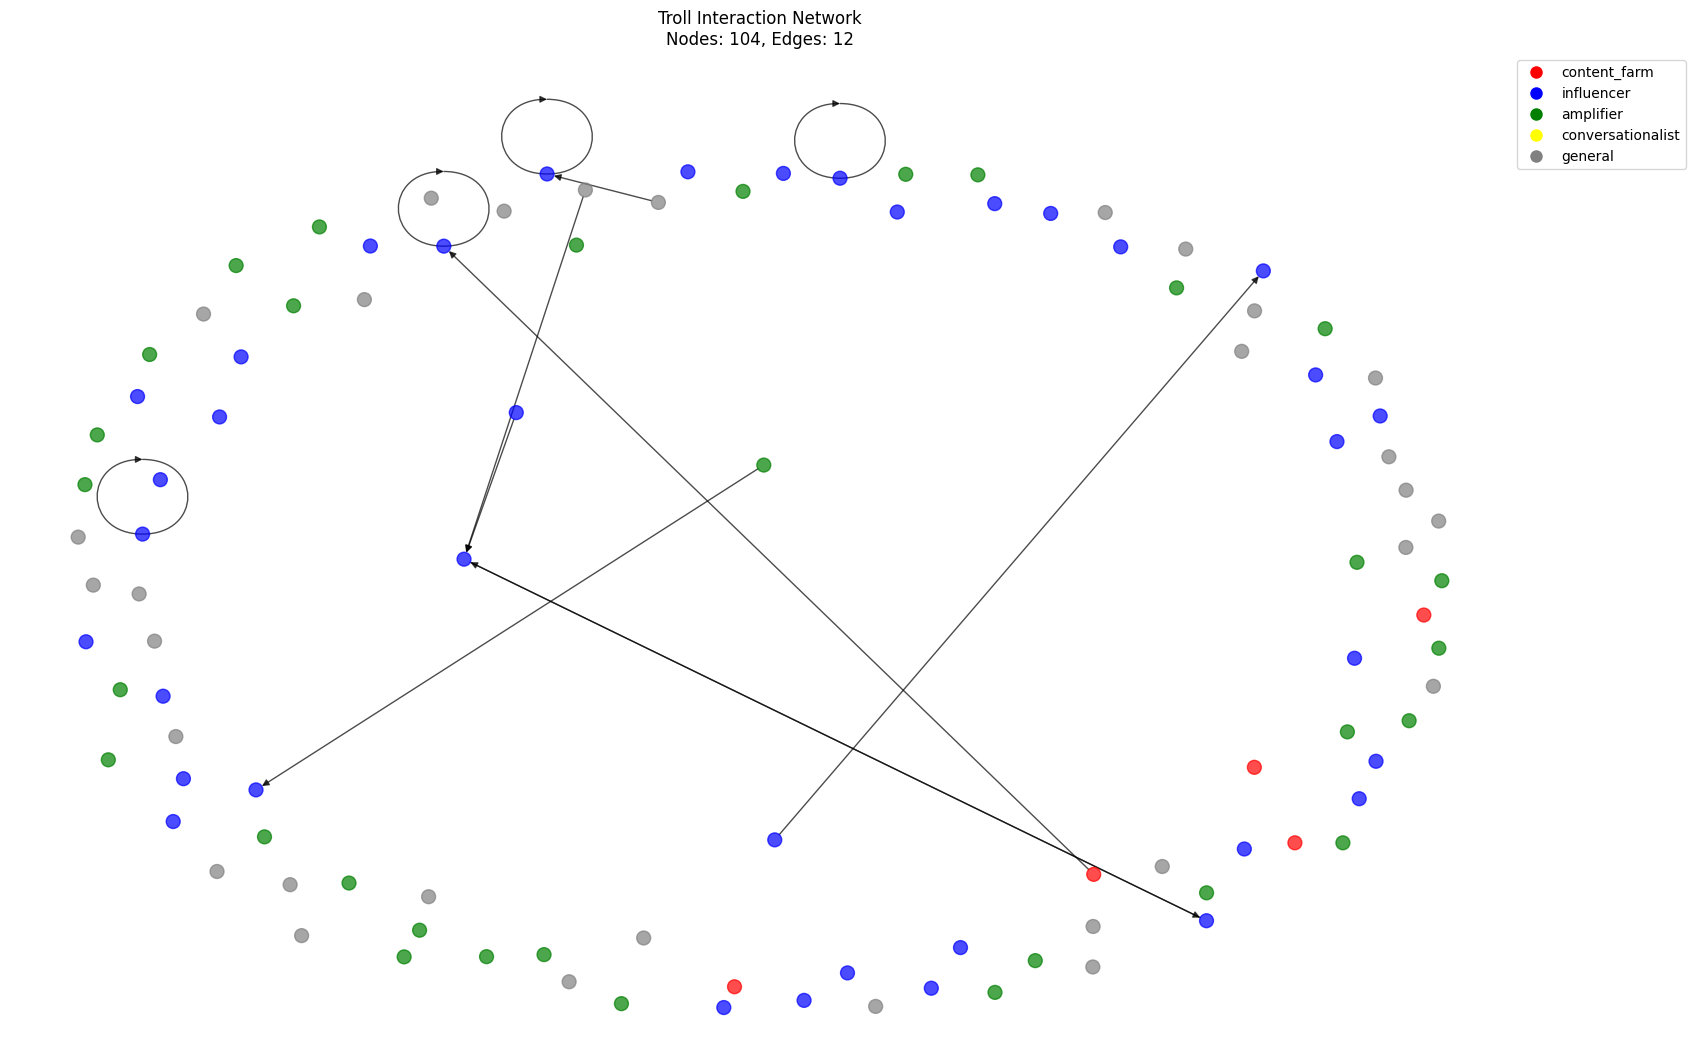


Analyzing interaction patterns...


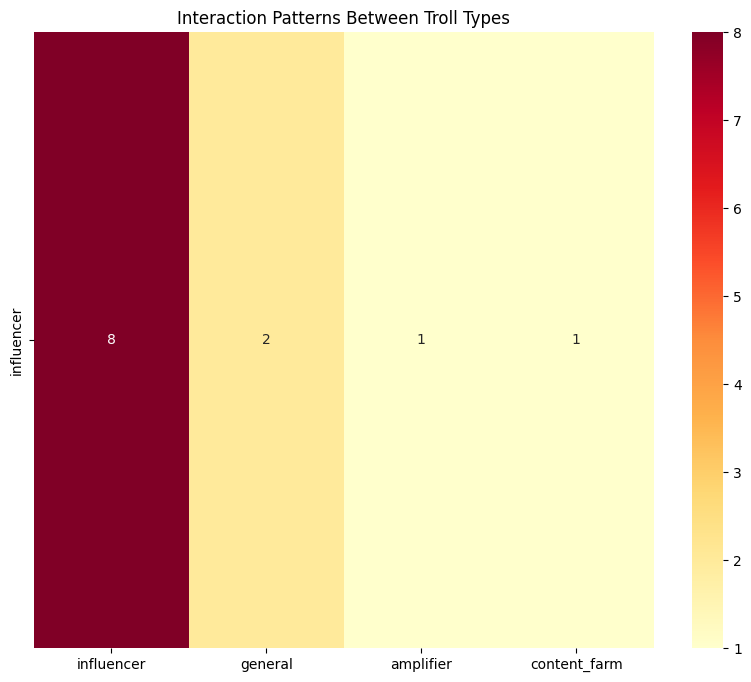


Interaction matrix:
            influencer  general  amplifier  content_farm
influencer           8        2          1             1


In [7]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast

# Read the data
tweets_df = pd.read_csv('tweets.csv')
users_df = pd.read_csv('users.csv')

def categorize_trolls(users_df, tweets_df):
    """
    Categorize trolls based on their behavior patterns
    Returns dictionary mapping user_key to their troll type
    """
    troll_categories = {}
    
    # Prepare tweets data
    tweets_df['hashtags'] = tweets_df['hashtags'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
    
    for _, user in users_df.iterrows():
        user_tweets = tweets_df[tweets_df['user_key'] == str(user['screen_name'])]
        tweet_count = len(user_tweets)
        
        if tweet_count == 0:
            continue
            
        # Calculate metrics
        retweet_count = user_tweets['retweeted_status_id'].notna().sum()
        reply_count = user_tweets['in_reply_to_status_id'].notna().sum()
        
        retweet_ratio = retweet_count / tweet_count if tweet_count > 0 else 0
        reply_ratio = reply_count / tweet_count if tweet_count > 0 else 0
        
        # Categorize based on behavior
        if user['statuses_count'] > 1000 and user['followers_count'] < 100:
            troll_categories[user['screen_name']] = 'content_farm'
        elif user['followers_count'] > 1000 and user['listed_count'] > 10:
            troll_categories[user['screen_name']] = 'influencer'
        elif retweet_ratio > 0.7:
            troll_categories[user['screen_name']] = 'amplifier'
        elif reply_ratio > 0.5:
            troll_categories[user['screen_name']] = 'conversationalist'
        else:
            troll_categories[user['screen_name']] = 'general'
            
    return troll_categories

def create_interaction_network(tweets_df, troll_categories):
    """Create a network showing interactions between different troll types"""
    G = nx.DiGraph()
    
    # Add nodes with troll type attribute
    for user, troll_type in troll_categories.items():
        G.add_node(user, troll_type=troll_type)
    
    # Add edges based on mentions
    tweets_df['mentions'] = tweets_df['mentions'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
    
    for _, row in tweets_df.iterrows():
        source = row['user_key']
        if source not in troll_categories:
            continue
            
        # Add mention edges
        for mention in row['mentions']:
            if mention in troll_categories:
                G.add_edge(source, mention, interaction_type='mention')
        
        # Add retweet edges
        if pd.notna(row['retweeted']) and row['retweeted'] in troll_categories:
            G.add_edge(source, row['retweeted'], interaction_type='retweet')
    
    return G

def plot_troll_network(G, title):
    """Plot network with nodes colored by troll type"""
    plt.figure(figsize=(15, 10))
    
    # Create layout
    pos = nx.spring_layout(G, k=1, iterations=50)
    
    # Get troll types for coloring
    troll_types = nx.get_node_attributes(G, 'troll_type')
    
    # Create color map
    color_map = {
        'content_farm': 'red',
        'influencer': 'blue',
        'amplifier': 'green',
        'conversationalist': 'yellow',
        'general': 'gray'
    }
    
    # Color nodes by troll type
    node_colors = [color_map[troll_types[node]] for node in G.nodes()]
    
    # Draw network
    nx.draw(G, pos,
           node_color=node_colors,
           node_size=100,
           alpha=0.7,
           with_labels=False)
    
    # Add legend
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                                 markerfacecolor=color, label=troll_type, markersize=10)
                      for troll_type, color in color_map.items()]
    plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))
    
    # Add title and metrics
    plt.title(f"{title}\nNodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
    
    plt.tight_layout()
    plt.show()

def analyze_troll_interactions(G):
    """Analyze interaction patterns between different troll types"""
    troll_types = nx.get_node_attributes(G, 'troll_type')
    
    # Create interaction matrix
    interaction_matrix = {}
    for source, target in G.edges():
        source_type = troll_types[source]
        target_type = troll_types[target]
        
        if source_type not in interaction_matrix:
            interaction_matrix[source_type] = {}
        if target_type not in interaction_matrix[source_type]:
            interaction_matrix[source_type][target_type] = 0
            
        interaction_matrix[source_type][target_type] += 1
    
    # Convert to DataFrame for better visualization
    df = pd.DataFrame(interaction_matrix).fillna(0)
    
    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(df, annot=True, fmt='g', cmap='YlOrRd')
    plt.title('Interaction Patterns Between Troll Types')
    plt.show()
    
    return df

def main():
    # Categorize trolls
    print("Categorizing trolls...")
    troll_categories = categorize_trolls(users_df, tweets_df)
    
    # Count troll types
    type_counts = Counter(troll_categories.values())
    print("\nTroll type distribution:")
    for troll_type, count in type_counts.items():
        print(f"{troll_type}: {count}")
    
    # Create and visualize interaction network
    print("\nCreating interaction network...")
    G = create_interaction_network(tweets_df, troll_categories)
    plot_troll_network(G, "Troll Interaction Network")
    
    # Analyze interaction patterns
    print("\nAnalyzing interaction patterns...")
    interaction_df = analyze_troll_interactions(G)
    print("\nInteraction matrix:")
    print(interaction_df)

if __name__ == "__main__":
    main()

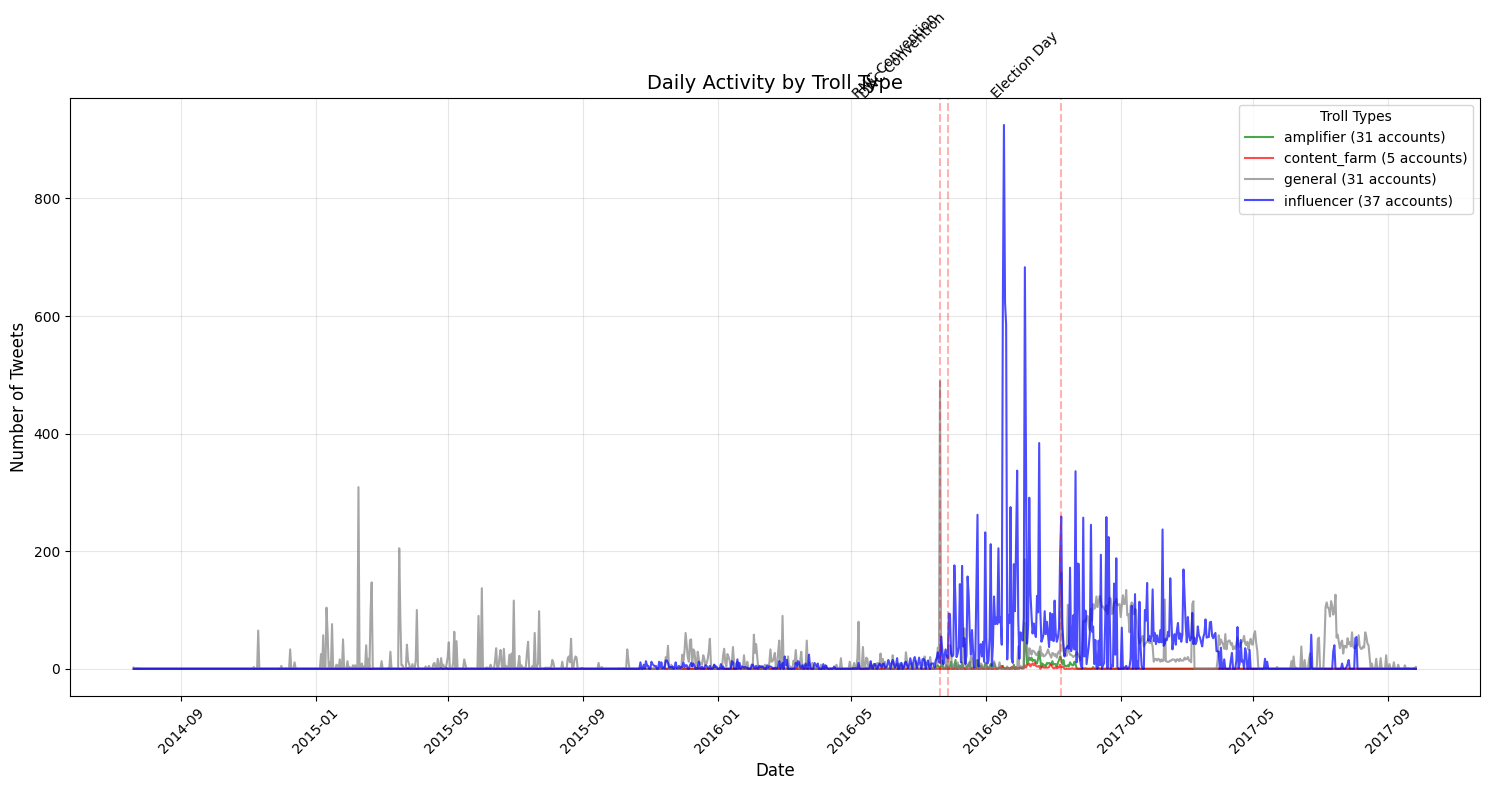


Activity around 2016-07-21 (RNC Convention)
Average daily tweets per troll type:

amplifier:
Before: 1.9
After: 3.7
Change: 100.0%

content_farm:
Before: 0.0
After: 0.0
Change: nan%

general:
Before: 9.1
After: 75.1
Change: 721.9%

influencer:
Before: 13.1
After: 26.3
Change: 100.0%

Activity around 2016-07-28 (DNC Convention)
Average daily tweets per troll type:

amplifier:
Before: 3.7
After: 2.4
Change: -34.6%

content_farm:
Before: 0.0
After: 0.0
Change: nan%

general:
Before: 75.1
After: 13.3
Change: -82.3%

influencer:
Before: 26.3
After: 64.4
Change: 145.1%

Activity around 2016-11-08 (Election Day)
Average daily tweets per troll type:

amplifier:
Before: 10.4
After: 8.4
Change: -19.2%

content_farm:
Before: 2.6
After: 1.3
Change: -50.0%

general:
Before: 24.9
After: 61.9
Change: 148.9%

influencer:
Before: 83.9
After: 72.6
Change: -13.5%


/var/folders/9x/h2cdc6094jzcrs4ch0f4r84c0000gn/T/ipykernel_7390/987047490.py:114: RuntimeWarning: invalid value encountered in scalar divide
  print(f"Change: {((after-before)/before*100):.1f}%")


In [10]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Define key dates
key_dates = {
    '2016-07-21': 'RNC Convention',
    '2016-07-28': 'DNC Convention', 
    '2016-11-08': 'Election Day'
}

# Read data
tweets_df = pd.read_csv('tweets.csv')
users_df = pd.read_csv('users.csv')

# Categorize trolls
def categorize_trolls(users_df, tweets_df):
    troll_categories = {}
    
    for _, user in users_df.iterrows():
        user_tweets = tweets_df[tweets_df['user_key'] == str(user['screen_name'])]
        tweet_count = len(user_tweets)
        
        if tweet_count == 0:
            continue
            
        # Calculate metrics
        retweet_count = user_tweets['retweeted_status_id'].notna().sum()
        reply_count = user_tweets['in_reply_to_status_id'].notna().sum()
        
        retweet_ratio = retweet_count / tweet_count if tweet_count > 0 else 0
        reply_ratio = reply_count / tweet_count if tweet_count > 0 else 0
        
        # Categorize based on behavior
        if user['statuses_count'] > 1000 and user['followers_count'] < 100:
            troll_categories[user['screen_name']] = 'content_farm'
        elif user['followers_count'] > 1000 and user['listed_count'] > 10:
            troll_categories[user['screen_name']] = 'influencer'
        elif retweet_ratio > 0.7:
            troll_categories[user['screen_name']] = 'amplifier'
        else:
            troll_categories[user['screen_name']] = 'general'
            
    return troll_categories

# Get troll categories
troll_categories = categorize_trolls(users_df, tweets_df)

# Count number of each troll type
troll_counts = {}
for troll_type in ['content_farm', 'influencer', 'amplifier', 'general']:
    troll_counts[troll_type] = list(troll_categories.values()).count(troll_type)

# Add categories to tweets
tweets_df['created_at'] = pd.to_datetime(tweets_df['created_str'])
tweets_df['troll_type'] = tweets_df['user_key'].map(troll_categories)

# Filter only tweets from categorized trolls
categorized_tweets = tweets_df[tweets_df['troll_type'].notna()]

# Create daily activity by troll type
daily_activity = categorized_tweets.set_index('created_at').groupby(['troll_type']).resample('D').size().reset_index()
daily_activity = daily_activity.pivot(index='created_at', columns='troll_type', values=0).fillna(0)

# Plot
plt.figure(figsize=(15, 8))

# Plot each troll type
colors = {'content_farm': 'red', 'influencer': 'blue', 'amplifier': 'green', 'general': 'gray'}
for troll_type in daily_activity.columns:
    plt.plot(daily_activity.index, daily_activity[troll_type], 
             label=f'{troll_type} ({troll_counts[troll_type]} accounts)',
             color=colors[troll_type], alpha=0.7)

# Add key dates
for date, event in key_dates.items():
    plt.axvline(x=pd.to_datetime(date), color='r', linestyle='--', alpha=0.3)
    plt.text(pd.to_datetime(date), plt.ylim()[1], event, rotation=45, ha='right')

plt.title('Daily Activity by Troll Type', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.legend(title='Troll Types')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print activity analysis around key dates
for date in key_dates:
    date = pd.to_datetime(date)
    window = 7  # days before/after
    
    print(f"\nActivity around {date.strftime('%Y-%m-%d')} ({key_dates[date.strftime('%Y-%m-%d')]})")
    print("Average daily tweets per troll type:")
    
    for troll_type in daily_activity.columns:
        before = daily_activity[troll_type][
            (daily_activity.index >= date - pd.Timedelta(days=window)) &
            (daily_activity.index < date)
        ].mean()
        
        after = daily_activity[troll_type][
            (daily_activity.index >= date) &
            (daily_activity.index < date + pd.Timedelta(days=window))
        ].mean()
        
        print(f"\n{troll_type}:")
        print(f"Before: {before:.1f}")
        print(f"After: {after:.1f}")
        print(f"Change: {((after-before)/before*100):.1f}%")

/var/folders/9x/h2cdc6094jzcrs4ch0f4r84c0000gn/T/ipykernel_7390/1879251164.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  troll_tweets['hashtags'] = troll_tweets['hashtags'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
/var/folders/9x/h2cdc6094jzcrs4ch0f4r84c0000gn/T/ipykernel_7390/1879251164.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  troll_tweets['hashtags'] = troll_tweets['hashtags'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
/var/folders/9x/h2cdc6094jzcrs4c

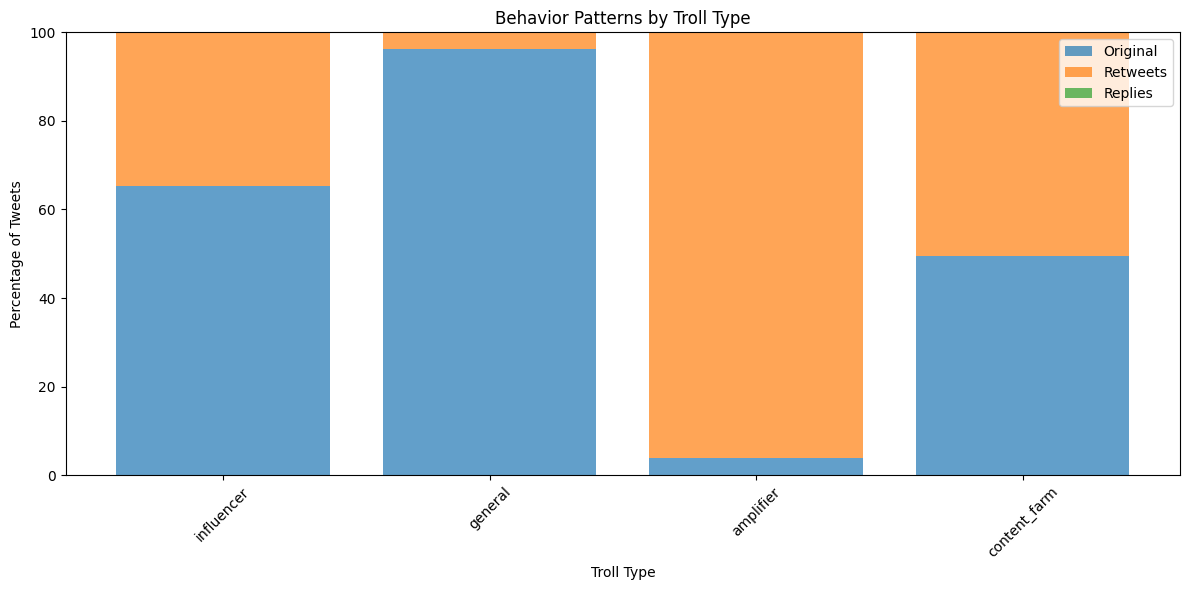


INFLUENCER TROLLS:
Total tweets: 22715
Tweet composition:
- Original: 65.2%
- Retweets: 34.7%
- Replies: 0.1%

Top hashtags:
- maga: 675
- Trump: 543
- tcot: 454
- NeverHillary: 355
- Hillary: 210

GENERAL TROLLS:
Total tweets: 19115
Tweet composition:
- Original: 96.2%
- Retweets: 3.8%
- Replies: 0.0%

Top hashtags:
- MerkelMussBleiben: 315
- news: 127
- Merkel: 115
- nowplaying: 104
- tcot: 80

AMPLIFIER TROLLS:
Total tweets: 813
Tweet composition:
- Original: 3.8%
- Retweets: 96.2%
- Replies: 0.0%

Top hashtags:
- Trump: 29
- Clinton: 16
- RejectedDebateTopics: 16
- imwithher: 16
- Debate: 15

CONTENT_FARM TROLLS:
Total tweets: 182
Tweet composition:
- Original: 49.5%
- Retweets: 50.5%
- Replies: 0.0%

Top hashtags:
- Foke: 84
- Debate: 3
- Trump: 3
- MTVEMAs: 2
- ImwithChickenAvocadoSubwayDressedwithSweetOnionAndDoubleHoneyMustard: 1


In [11]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Read data
tweets_df = pd.read_csv('tweets.csv')
users_df = pd.read_csv('users.csv')

# Categorize trolls first
def categorize_trolls(users_df, tweets_df):
    troll_categories = {}
    
    for _, user in users_df.iterrows():
        user_tweets = tweets_df[tweets_df['user_key'] == str(user['screen_name'])]
        tweet_count = len(user_tweets)
        
        if tweet_count == 0:
            continue
            
        # Calculate metrics
        retweet_count = user_tweets['retweeted_status_id'].notna().sum()
        reply_count = user_tweets['in_reply_to_status_id'].notna().sum()
        
        retweet_ratio = retweet_count / tweet_count if tweet_count > 0 else 0
        reply_ratio = reply_count / tweet_count if tweet_count > 0 else 0
        
        if user['statuses_count'] > 1000 and user['followers_count'] < 100:
            troll_categories[user['screen_name']] = 'content_farm'
        elif user['followers_count'] > 1000 and user['listed_count'] > 10:
            troll_categories[user['screen_name']] = 'influencer'
        elif retweet_ratio > 0.7:
            troll_categories[user['screen_name']] = 'amplifier'
        else:
            troll_categories[user['screen_name']] = 'general'
            
    return troll_categories

# Get troll categories
troll_categories = categorize_trolls(users_df, tweets_df)

# Add categories to tweets
tweets_df['troll_type'] = tweets_df['user_key'].map(troll_categories)

# Filter only categorized trolls
categorized_tweets = tweets_df[tweets_df['troll_type'].notna()]

# Analyze behavior by type
def analyze_troll_behavior(tweets_df):
    behaviors = {}
    
    for troll_type in tweets_df['troll_type'].unique():
        troll_tweets = tweets_df[tweets_df['troll_type'] == troll_type]
        
        # Calculate basic metrics
        total_tweets = len(troll_tweets)
        retweets = troll_tweets['retweeted_status_id'].notna().sum()
        replies = troll_tweets['in_reply_to_status_id'].notna().sum()
        original = total_tweets - retweets - replies
        
        # Convert hashtags from string to list and count them
        troll_tweets['hashtags'] = troll_tweets['hashtags'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
        hashtags = [tag for tags in troll_tweets['hashtags'] for tag in tags]
        top_hashtags = pd.Series(hashtags).value_counts().head(5)
        
        behaviors[troll_type] = {
            'total_tweets': total_tweets,
            'retweets_ratio': retweets/total_tweets if total_tweets > 0 else 0,
            'replies_ratio': replies/total_tweets if total_tweets > 0 else 0,
            'original_ratio': original/total_tweets if total_tweets > 0 else 0,
            'top_hashtags': top_hashtags
        }
    
    return behaviors

# Get behavior analysis
behaviors = analyze_troll_behavior(categorized_tweets)

# Plot behavior patterns
plt.figure(figsize=(12, 6))

# Prepare data for plotting
types = list(behaviors.keys())
retweets = [b['retweets_ratio'] * 100 for b in behaviors.values()]
replies = [b['replies_ratio'] * 100 for b in behaviors.values()]
original = [b['original_ratio'] * 100 for b in behaviors.values()]

# Create stacked bar chart
bar_width = 0.35
plt.bar(types, original, label='Original', alpha=0.7)
plt.bar(types, retweets, bottom=original, label='Retweets', alpha=0.7)
plt.bar(types, replies, bottom=[o+r for o,r in zip(original, retweets)], label='Replies', alpha=0.7)

plt.title('Behavior Patterns by Troll Type')
plt.xlabel('Troll Type')
plt.ylabel('Percentage of Tweets')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print detailed analysis
for troll_type, behavior in behaviors.items():
    print(f"\n{troll_type.upper()} TROLLS:")
    print(f"Total tweets: {behavior['total_tweets']}")
    print(f"Tweet composition:")
    print(f"- Original: {behavior['original_ratio']*100:.1f}%")
    print(f"- Retweets: {behavior['retweets_ratio']*100:.1f}%")
    print(f"- Replies: {behavior['replies_ratio']*100:.1f}%")
    print("\nTop hashtags:")
    for tag, count in behavior['top_hashtags'].items():
        print(f"- {tag}: {count}")

In [12]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

# Read data
tweets_df = pd.read_csv('tweets.csv')
users_df = pd.read_csv('users.csv')

# Categorize trolls
def categorize_trolls(users_df, tweets_df):
    troll_categories = {}
    
    for _, user in users_df.iterrows():
        user_tweets = tweets_df[tweets_df['user_key'] == str(user['screen_name'])]
        tweet_count = len(user_tweets)
        
        if tweet_count == 0:
            continue
            
        retweet_count = user_tweets['retweeted_status_id'].notna().sum()
        retweet_ratio = retweet_count / tweet_count if tweet_count > 0 else 0
        
        if user['statuses_count'] > 1000 and user['followers_count'] < 100:
            troll_categories[user['screen_name']] = 'content_farm'
        elif user['followers_count'] > 1000 and user['listed_count'] > 10:
            troll_categories[user['screen_name']] = 'influencer'
        elif retweet_ratio > 0.7:
            troll_categories[user['screen_name']] = 'amplifier'
        else:
            troll_categories[user['screen_name']] = 'general'
            
    return troll_categories

# Get troll categories
troll_categories = categorize_trolls(users_df, tweets_df)

# Add categories to tweets
tweets_df['troll_type'] = tweets_df['user_key'].map(troll_categories)

# Convert hashtags from string to list
tweets_df['hashtags'] = tweets_df['hashtags'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

# Analyze hashtags by troll type
def analyze_hashtags(tweets_df):
    hashtags_by_type = {}
    
    for troll_type in tweets_df['troll_type'].unique():
        if pd.isna(troll_type):
            continue
            
        # Get all hashtags for this troll type
        troll_tweets = tweets_df[tweets_df['troll_type'] == troll_type]
        all_hashtags = [tag for tags in troll_tweets['hashtags'] for tag in tags]
        
        # Count hashtags
        hashtag_counts = Counter(all_hashtags)
        top_hashtags = pd.Series(hashtag_counts).nlargest(10)
        
        hashtags_by_type[troll_type] = top_hashtags
    
    return hashtags_by_type

# Get hashtag analysis
hashtags_by_type = analyze_hashtags(tweets_df)

# Print results for each troll type
for troll_type, hashtags in hashtags_by_type.items():
    print(f"\n{troll_type.upper()} TROLLS TOP HASHTAGS:")
    print("------------------------------")
    for hashtag, count in hashtags.items():
        print(f"{hashtag}: {count}")


INFLUENCER TROLLS TOP HASHTAGS:
------------------------------
maga: 675
Trump: 543
tcot: 454
NeverHillary: 355
Hillary: 210
TrumpPence16: 199
pjnet: 197
Obama: 143
teapartynews: 135
SurvivalGuideToThanksgiving: 133

GENERAL TROLLS TOP HASHTAGS:
------------------------------
MerkelMussBleiben: 315
news: 127
Merkel: 115
nowplaying: 104
tcot: 80
p2: 70
Iamonfire: 64
PodernFamily: 64
Blacklivesmatter: 60
RealLifeMagicSpells: 55

AMPLIFIER TROLLS TOP HASHTAGS:
------------------------------
Trump: 29
imwithher: 16
Clinton: 16
RejectedDebateTopics: 16
Debate: 15
RNCinCLE: 14
debatenight: 14
TrumpsFavoriteHeadline: 12
debates: 11
ObamasWishList: 10

CONTENT_FARM TROLLS TOP HASHTAGS:
------------------------------
Foke: 84
Debate: 3
Trump: 3
MTVEMAs: 2
ElectionResults: 1
majorL: 1
ImwithChickenAvocadoSubwayDressedwithSweetOnionAndDoubleHoneyMustard: 1
ImWithHumusMarshmallowsPeanutButterSteakRibeye: 1
WomenWhoVoteTrump: 1
Flint: 1


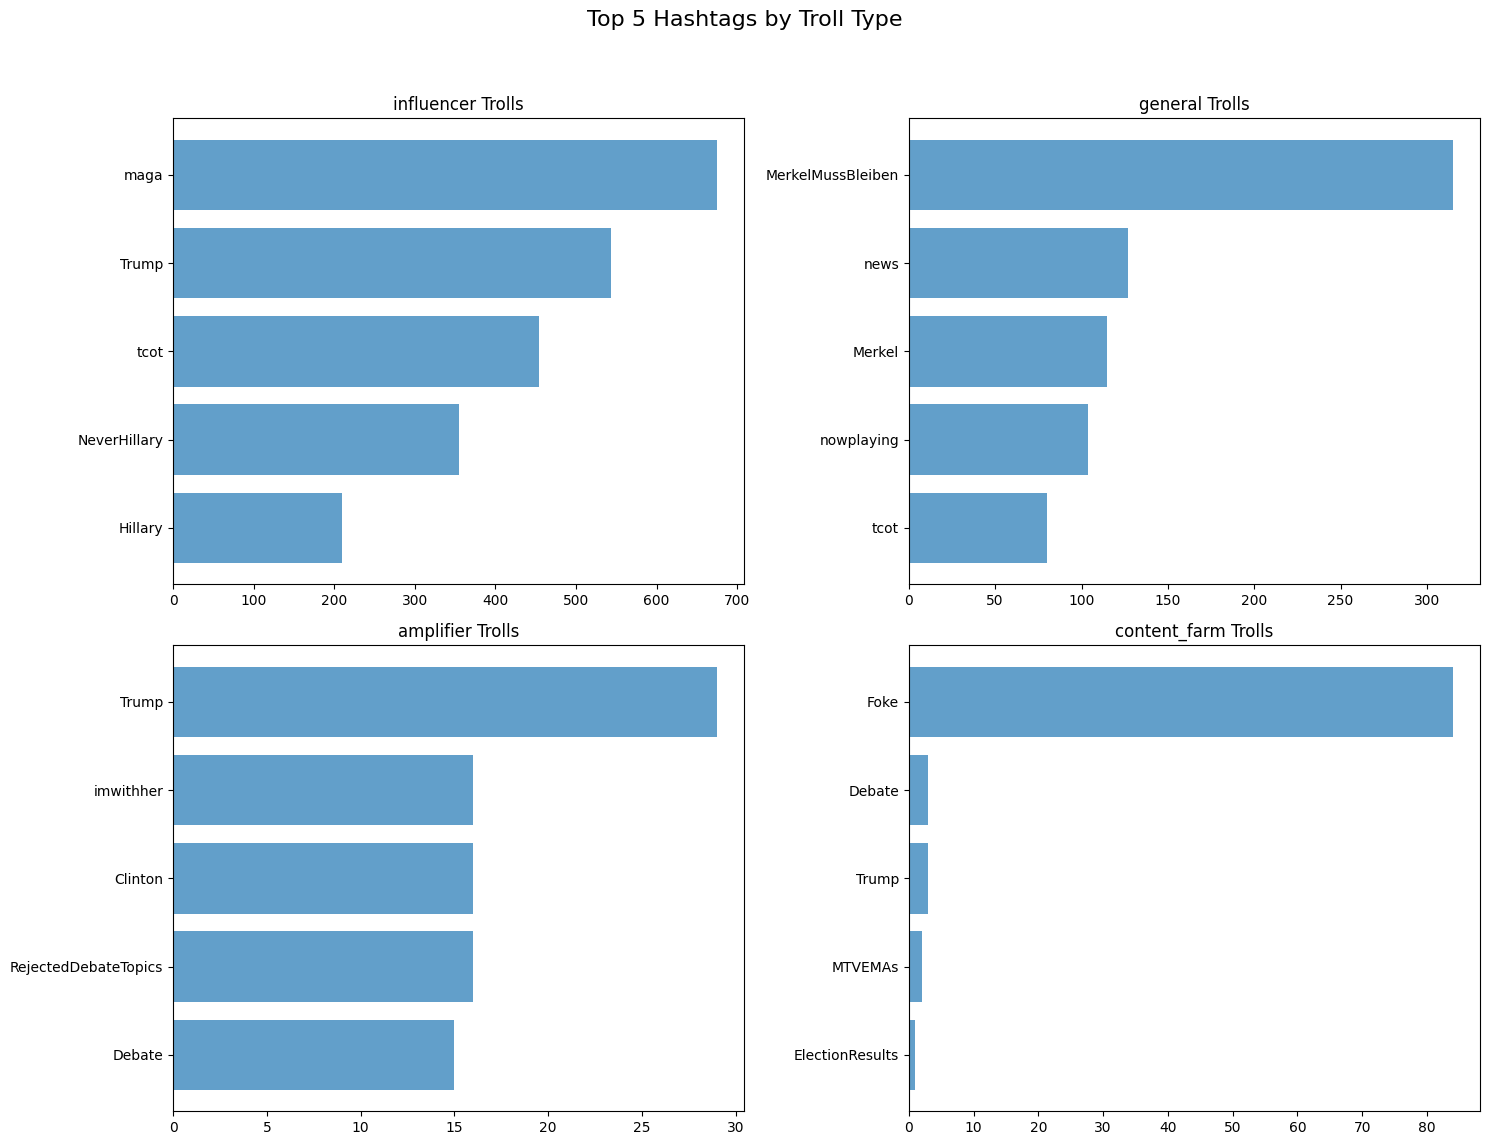


HASHTAG OVERLAP (top 10):
-------------------------

general & influencer share these hashtags:
{'tcot'}

amplifier & influencer share these hashtags:
{'Trump'}

amplifier & content_farm share these hashtags:
{'Debate', 'Trump'}

content_farm & influencer share these hashtags:
{'Trump'}


In [13]:
# Create visualization of top 5 hashtags for each type
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Top 5 Hashtags by Troll Type', fontsize=16)

for (troll_type, hashtags), ax in zip(hashtags_by_type.items(), axes.flat):
    # Get top 5 hashtags
    top_5 = hashtags.head(5)
    
    # Create bar plot
    ax.barh(top_5.index, top_5.values, alpha=0.7)
    ax.set_title(f'{troll_type} Trolls')
    ax.invert_yaxis()  # Invert y-axis to show highest values at top
    
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Calculate hashtag overlap
def calculate_hashtag_overlap():
    hashtag_sets = {}
    for troll_type in hashtags_by_type:
        hashtag_sets[troll_type] = set(hashtags_by_type[troll_type].head(10).index)
    
    print("\nHASHTAG OVERLAP (top 10):")
    print("-------------------------")
    for type1 in hashtag_sets:
        for type2 in hashtag_sets:
            if type1 < type2:
                overlap = hashtag_sets[type1] & hashtag_sets[type2]
                if overlap:
                    print(f"\n{type1} & {type2} share these hashtags:")
                    print(overlap)

calculate_hashtag_overlap()

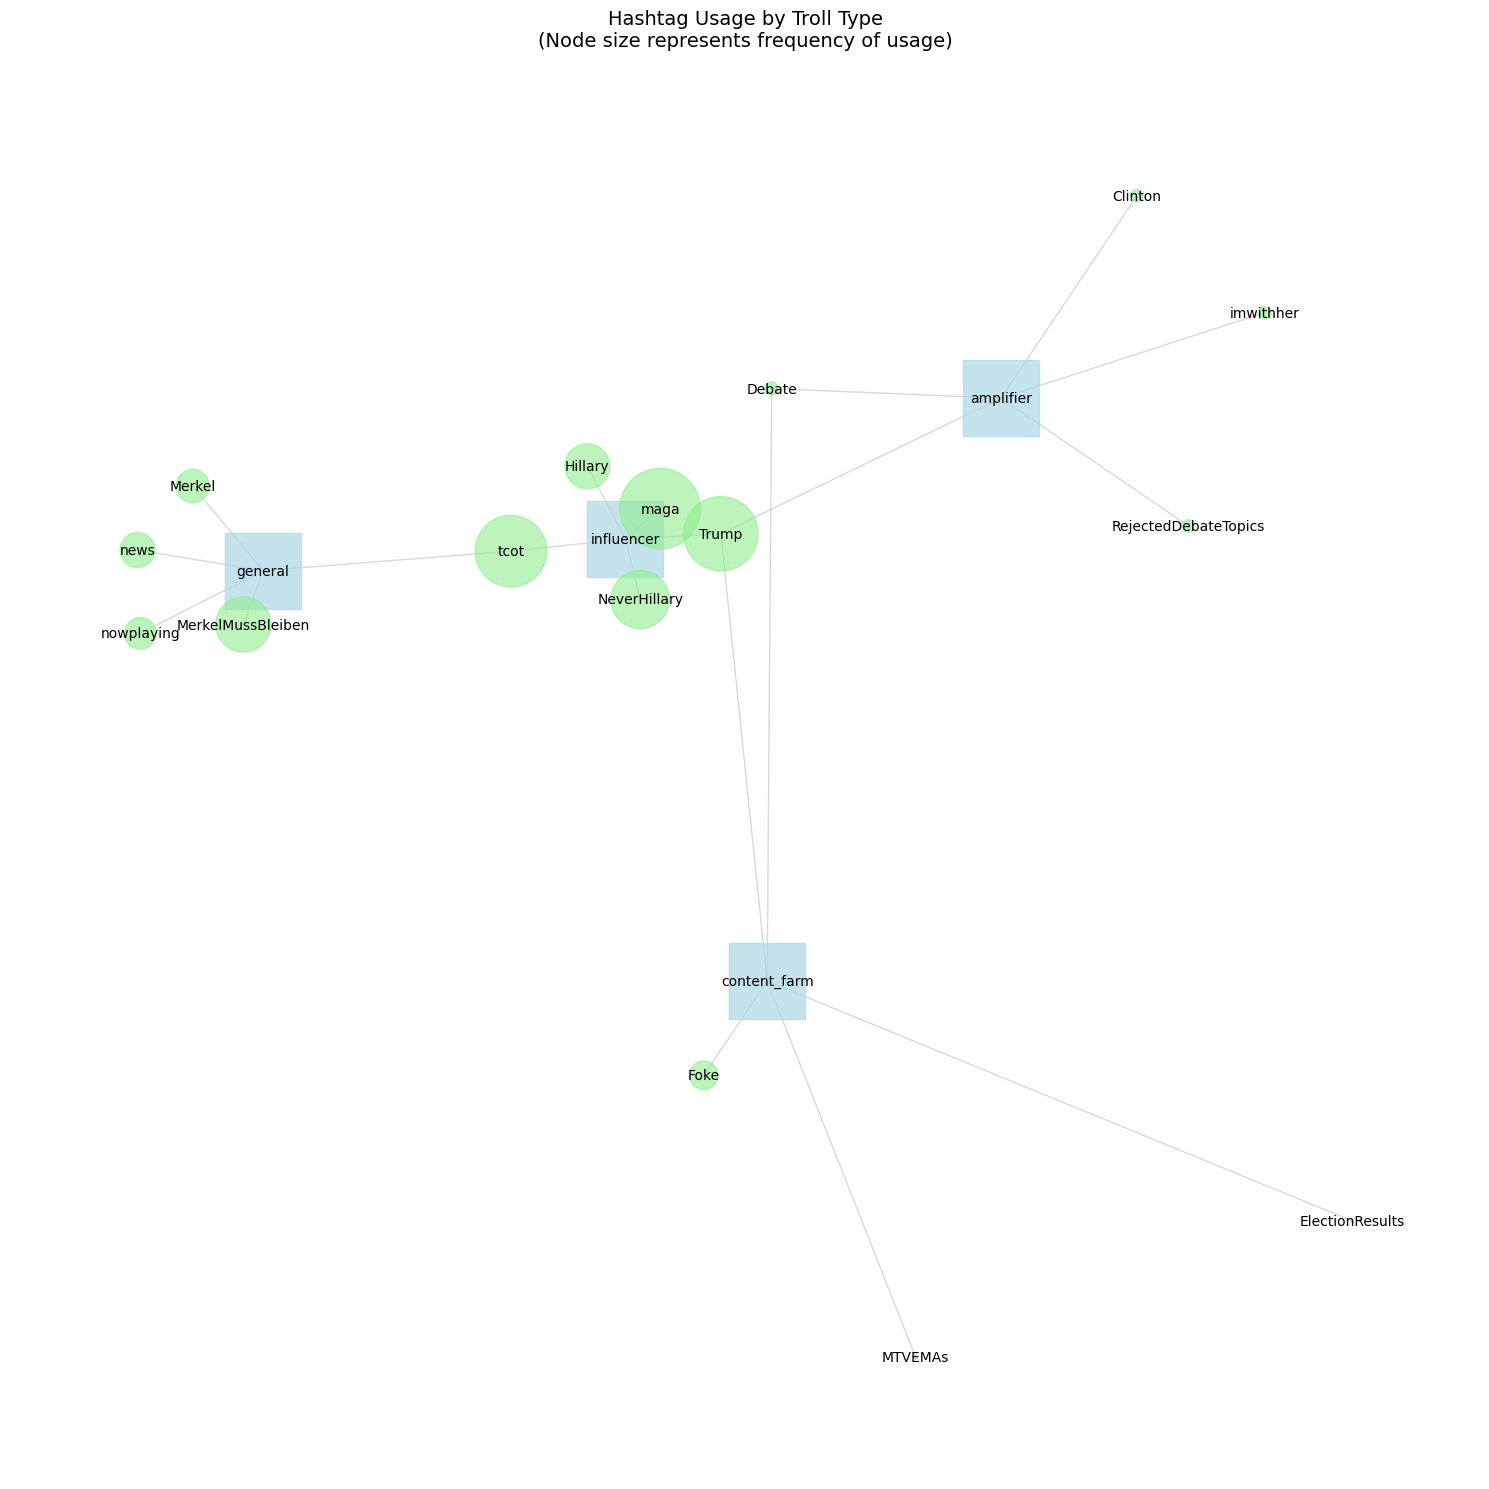


Most used hashtags overall:
maga: 675
Trump: 575
tcot: 534
NeverHillary: 355
MerkelMussBleiben: 315
Hillary: 210
news: 127
Merkel: 115
nowplaying: 104
Foke: 84

Hashtags by troll type:

INFLUENCER:
maga: 675
Trump: 543
tcot: 454
NeverHillary: 355
Hillary: 210

GENERAL:
MerkelMussBleiben: 315
news: 127
Merkel: 115
nowplaying: 104
tcot: 80

AMPLIFIER:
Trump: 29
imwithher: 16
Clinton: 16
RejectedDebateTopics: 16
Debate: 15

CONTENT_FARM:
Foke: 84
Debate: 3
Trump: 3
MTVEMAs: 2
ElectionResults: 1


In [14]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import ast
from collections import Counter

# Read and prepare data
tweets_df = pd.read_csv('tweets.csv')
users_df = pd.read_csv('users.csv')

# Categorize trolls
def categorize_trolls(users_df, tweets_df):
    troll_categories = {}
    for _, user in users_df.iterrows():
        user_tweets = tweets_df[tweets_df['user_key'] == str(user['screen_name'])]
        tweet_count = len(user_tweets)
        
        if tweet_count == 0:
            continue
            
        retweet_count = user_tweets['retweeted_status_id'].notna().sum()
        retweet_ratio = retweet_count / tweet_count if tweet_count > 0 else 0
        
        if user['statuses_count'] > 1000 and user['followers_count'] < 100:
            troll_categories[user['screen_name']] = 'content_farm'
        elif user['followers_count'] > 1000 and user['listed_count'] > 10:
            troll_categories[user['screen_name']] = 'influencer'
        elif retweet_ratio > 0.7:
            troll_categories[user['screen_name']] = 'amplifier'
        else:
            troll_categories[user['screen_name']] = 'general'
            
    return troll_categories

# Get troll categories
troll_categories = categorize_trolls(users_df, tweets_df)
tweets_df['troll_type'] = tweets_df['user_key'].map(troll_categories)
tweets_df['hashtags'] = tweets_df['hashtags'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

# Get top 5 hashtags for each troll type
def get_top_hashtags():
    hashtags_by_type = {}
    for troll_type in tweets_df['troll_type'].unique():
        if pd.isna(troll_type):
            continue
        troll_tweets = tweets_df[tweets_df['troll_type'] == troll_type]
        all_hashtags = [tag for tags in troll_tweets['hashtags'] for tag in tags]
        hashtag_counts = Counter(all_hashtags)
        hashtags_by_type[troll_type] = dict(hashtag_counts.most_common(5))
    return hashtags_by_type

# Create network
G = nx.Graph()

# Add nodes and edges
hashtags_by_type = get_top_hashtags()

# Add troll type nodes (will be squares)
for troll_type in hashtags_by_type.keys():
    G.add_node(troll_type, node_type='troll')

# Add hashtag nodes and edges
all_hashtag_counts = Counter()
for troll_type, hashtags in hashtags_by_type.items():
    for hashtag, count in hashtags.items():
        G.add_node(hashtag, node_type='hashtag', count=count)
        G.add_edge(troll_type, hashtag, weight=count)
        all_hashtag_counts[hashtag] += count

# Create the plot
plt.figure(figsize=(15, 15))

# Define layout
pos = nx.spring_layout(G, k=1, iterations=50)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray')

# Draw nodes
troll_nodes = [node for node, attr in G.nodes(data=True) if attr.get('node_type') == 'troll']
hashtag_nodes = [node for node, attr in G.nodes(data=True) if attr.get('node_type') == 'hashtag']

# Draw troll type nodes (squares)
nx.draw_networkx_nodes(G, pos, nodelist=troll_nodes, 
                      node_color='lightblue',
                      node_shape='s',
                      node_size=3000,
                      alpha=0.7)

# Draw hashtag nodes (circles with varying sizes)
sizes = [all_hashtag_counts[node] * 5 for node in hashtag_nodes]
nx.draw_networkx_nodes(G, pos, nodelist=hashtag_nodes,
                      node_color='lightgreen',
                      node_size=sizes,
                      alpha=0.6)

# Add labels
labels = {node: node for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=10)

plt.title("Hashtag Usage by Troll Type\n(Node size represents frequency of usage)", 
         pad=20, size=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print statistics
print("\nMost used hashtags overall:")
for hashtag, count in all_hashtag_counts.most_common(10):
    print(f"{hashtag}: {count}")

print("\nHashtags by troll type:")
for troll_type, hashtags in hashtags_by_type.items():
    print(f"\n{troll_type.upper()}:")
    for hashtag, count in hashtags.items():
        print(f"{hashtag}: {count}")

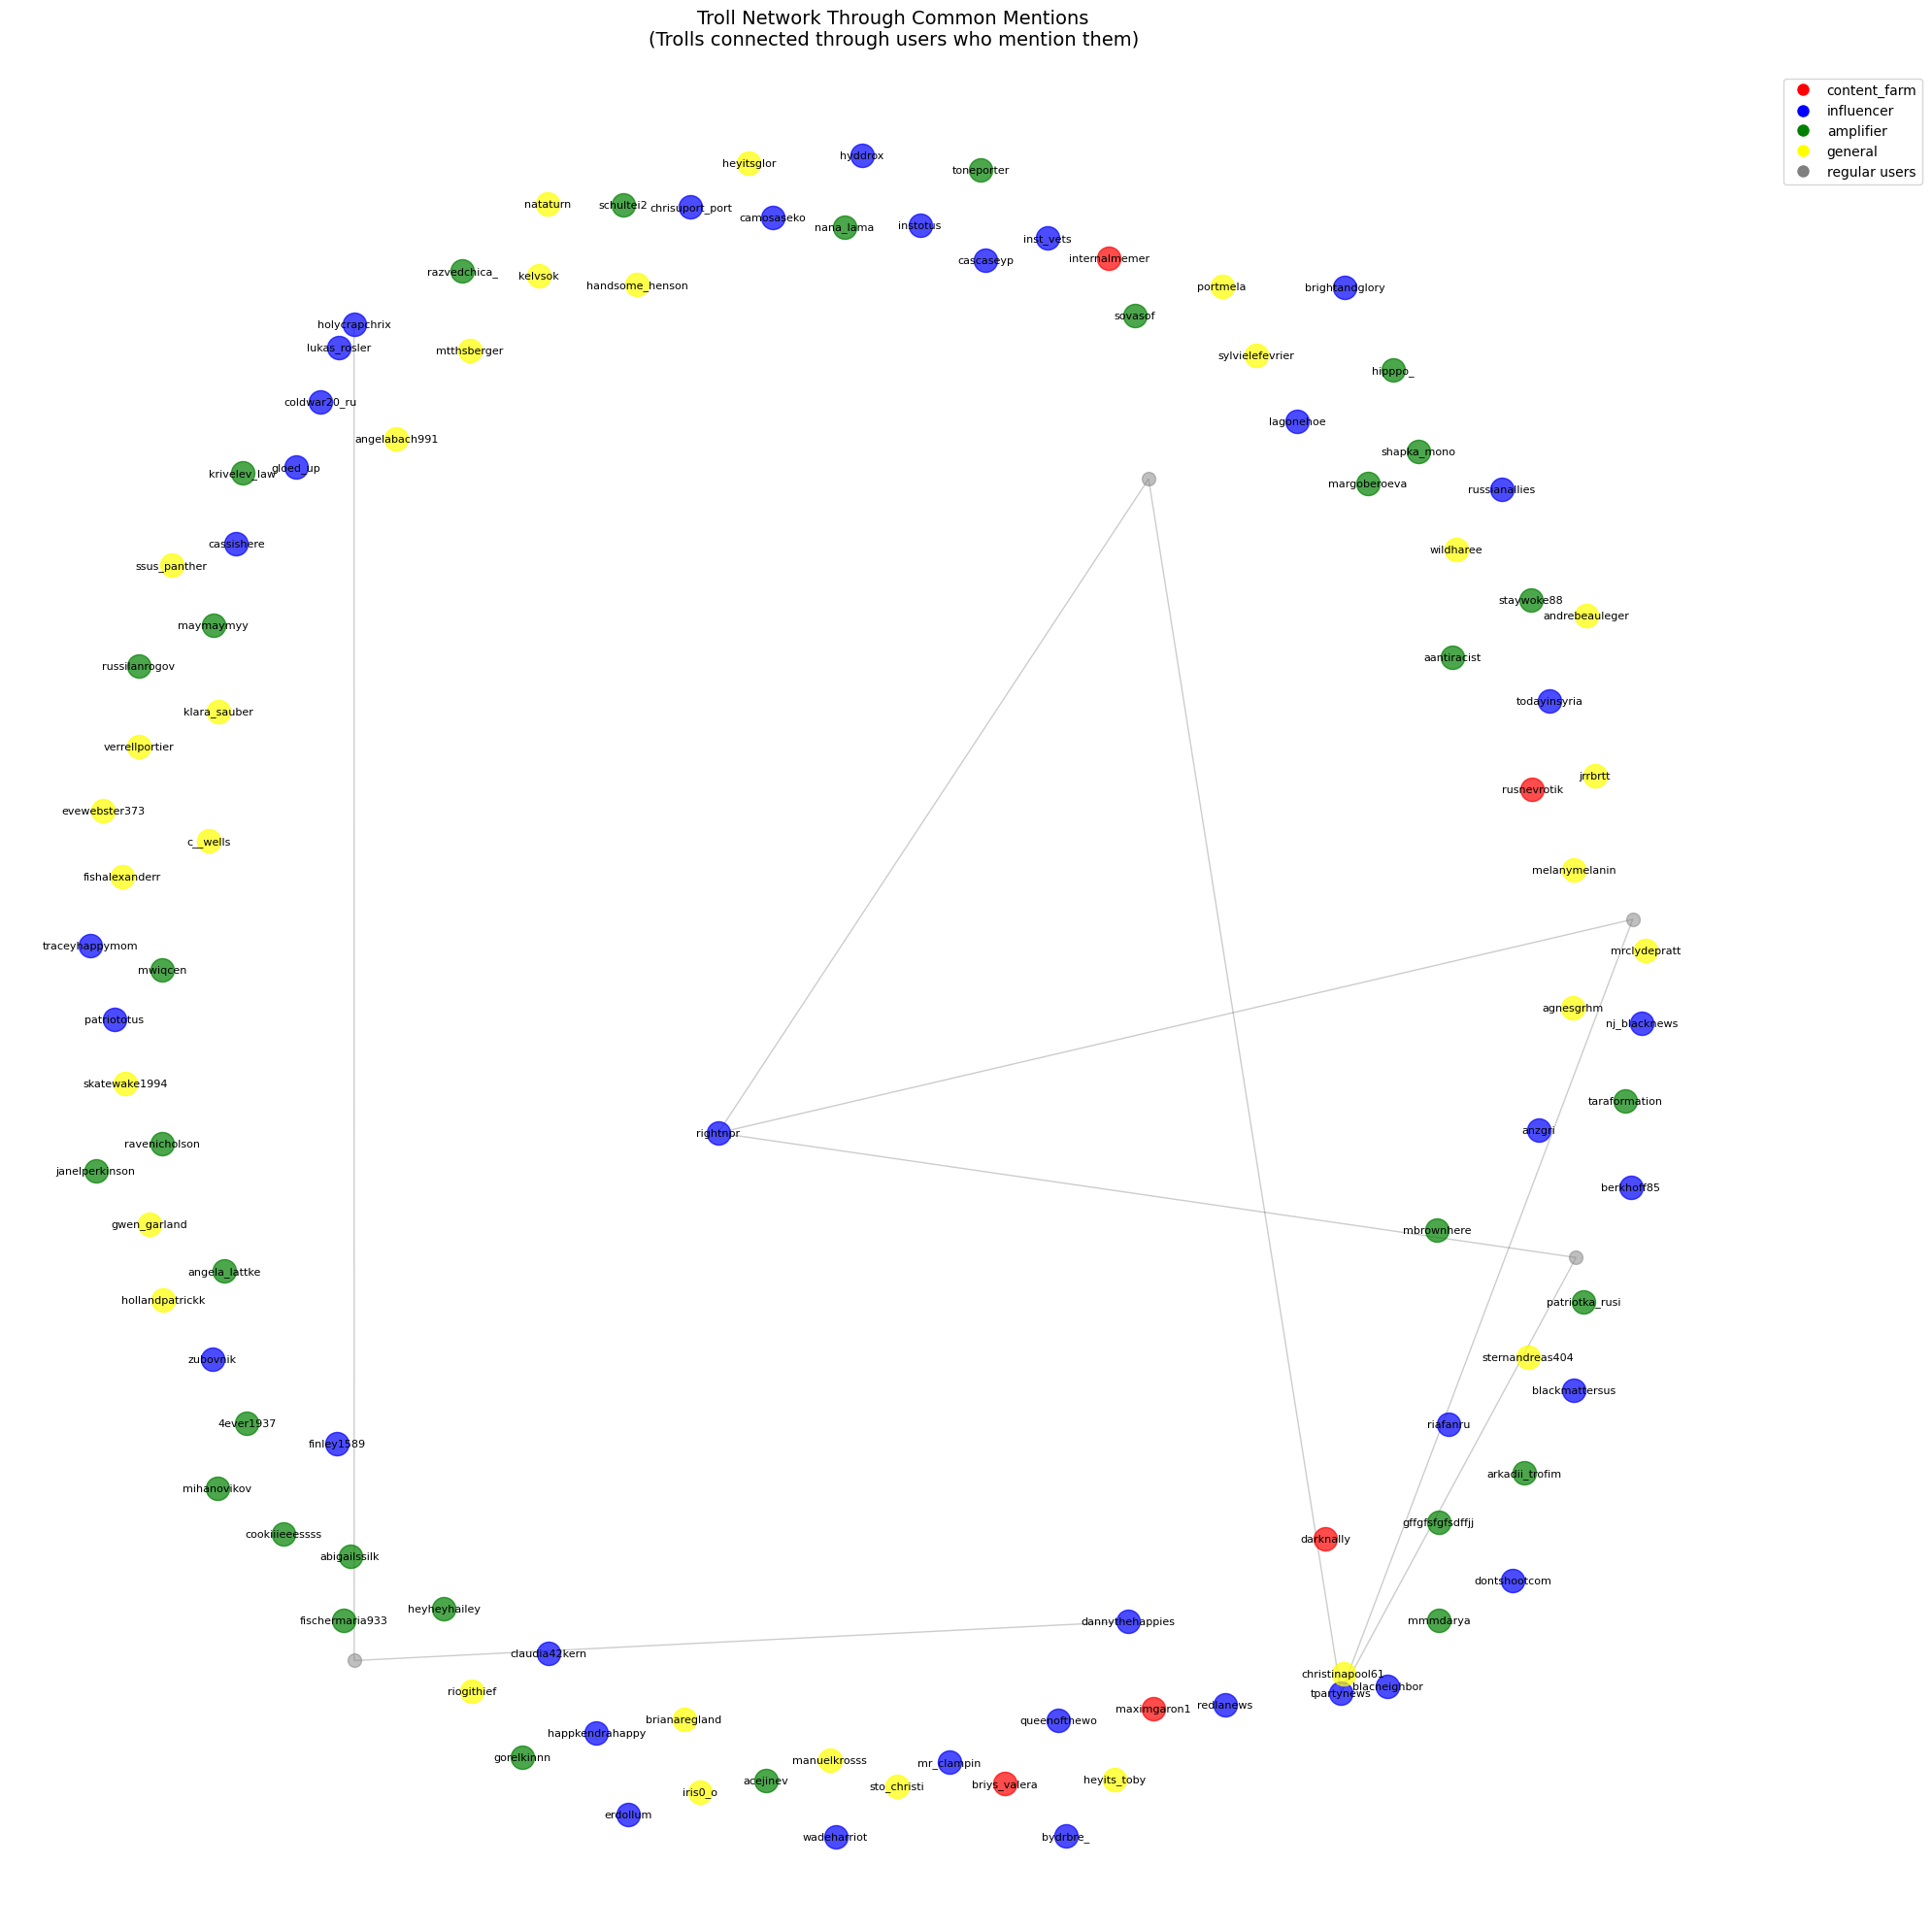


Network Statistics:
Number of nodes: 108
Number of edges: 8

Number of nodes by type:
general: 31
content_farm: 5
influencer: 37
amplifier: 31
regular_users: 4


In [15]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import ast
from collections import defaultdict

# Read data
tweets_df = pd.read_csv('tweets.csv')
users_df = pd.read_csv('users.csv')

# Categorize trolls
def categorize_trolls(users_df, tweets_df):
    troll_categories = {}
    for _, user in users_df.iterrows():
        user_tweets = tweets_df[tweets_df['user_key'] == str(user['screen_name'])]
        tweet_count = len(user_tweets)
        
        if tweet_count == 0:
            continue
            
        retweet_count = user_tweets['retweeted_status_id'].notna().sum()
        retweet_ratio = retweet_count / tweet_count if tweet_count > 0 else 0
        
        if user['statuses_count'] > 1000 and user['followers_count'] < 100:
            troll_categories[user['screen_name']] = 'content_farm'
        elif user['followers_count'] > 1000 and user['listed_count'] > 10:
            troll_categories[user['screen_name']] = 'influencer'
        elif retweet_ratio > 0.7:
            troll_categories[user['screen_name']] = 'amplifier'
        else:
            troll_categories[user['screen_name']] = 'general'
            
    return troll_categories

# Get troll categories
troll_categories = categorize_trolls(users_df, tweets_df)

# Convert mentions to list and create mention network
tweets_df['mentions'] = tweets_df['mentions'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

# Create a dictionary of users who mention trolls
users_mentioning_trolls = defaultdict(set)
trolls_mentioned_by_users = defaultdict(set)

# Analyze mentions
for _, tweet in tweets_df.iterrows():
    user = tweet['user_key']
    mentions = tweet['mentions']
    
    # Check if any mentioned users are trolls
    mentioned_trolls = [mention for mention in mentions if mention in troll_categories]
    if mentioned_trolls:
        users_mentioning_trolls[user].update(mentioned_trolls)
        
    # If the user is a troll, record who they mention
    if user in troll_categories:
        trolls_mentioned_by_users[user].update(mentions)

# Create network
G = nx.Graph()

# Add troll nodes with their categories
for troll, category in troll_categories.items():
    G.add_node(troll, node_type='troll', category=category)

# Add connections through common users
for user, mentioned_trolls in users_mentioning_trolls.items():
    if len(mentioned_trolls) > 1:  # Only if user mentions multiple trolls
        mentioned_trolls = list(mentioned_trolls)
        # Add user node
        if user not in troll_categories:  # Only if the user is not a troll
            G.add_node(user, node_type='user')
            # Connect user to trolls
            for troll in mentioned_trolls:
                G.add_edge(user, troll)

# Plot the network
plt.figure(figsize=(20, 20))

# Create layout
pos = nx.spring_layout(G, k=1, iterations=50)

# Define colors for different node types
color_map = {
    'content_farm': 'red',
    'influencer': 'blue',
    'amplifier': 'green',
    'general': 'yellow'
}

# Draw nodes by type
for node_type in ['user', 'troll']:
    if node_type == 'user':
        # Draw regular users
        user_nodes = [node for node, attr in G.nodes(data=True) 
                     if attr.get('node_type') == 'user']
        nx.draw_networkx_nodes(G, pos, nodelist=user_nodes,
                             node_color='gray',
                             node_size=100,
                             alpha=0.5)
    else:
        # Draw trolls by category
        for category in color_map:
            troll_nodes = [node for node, attr in G.nodes(data=True)
                          if attr.get('node_type') == 'troll' and 
                          attr.get('category') == category]
            nx.draw_networkx_nodes(G, pos, nodelist=troll_nodes,
                                 node_color=color_map[category],
                                 node_size=300,
                                 alpha=0.7)

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.2)

# Add labels only for troll nodes
troll_labels = {node: node for node, attr in G.nodes(data=True) 
                if attr.get('node_type') == 'troll'}
nx.draw_networkx_labels(G, pos, labels=troll_labels, font_size=8)

# Add legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                             markerfacecolor=color, label=category,
                             markersize=10)
                  for category, color in color_map.items()]
legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                 markerfacecolor='gray', label='regular users',
                                 markersize=10))
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.title("Troll Network Through Common Mentions\n(Trolls connected through users who mention them)",
         pad=20, size=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print some statistics
print("\nNetwork Statistics:")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print("\nNumber of nodes by type:")
node_types = {}
for node, attr in G.nodes(data=True):
    if attr.get('node_type') == 'troll':
        category = attr.get('category')
        node_types[category] = node_types.get(category, 0) + 1
    else:
        node_types['regular_users'] = node_types.get('regular_users', 0) + 1
for node_type, count in node_types.items():
    print(f"{node_type}: {count}")

Finding communities...
Number of trolls in graph: 104
Found 142 paths


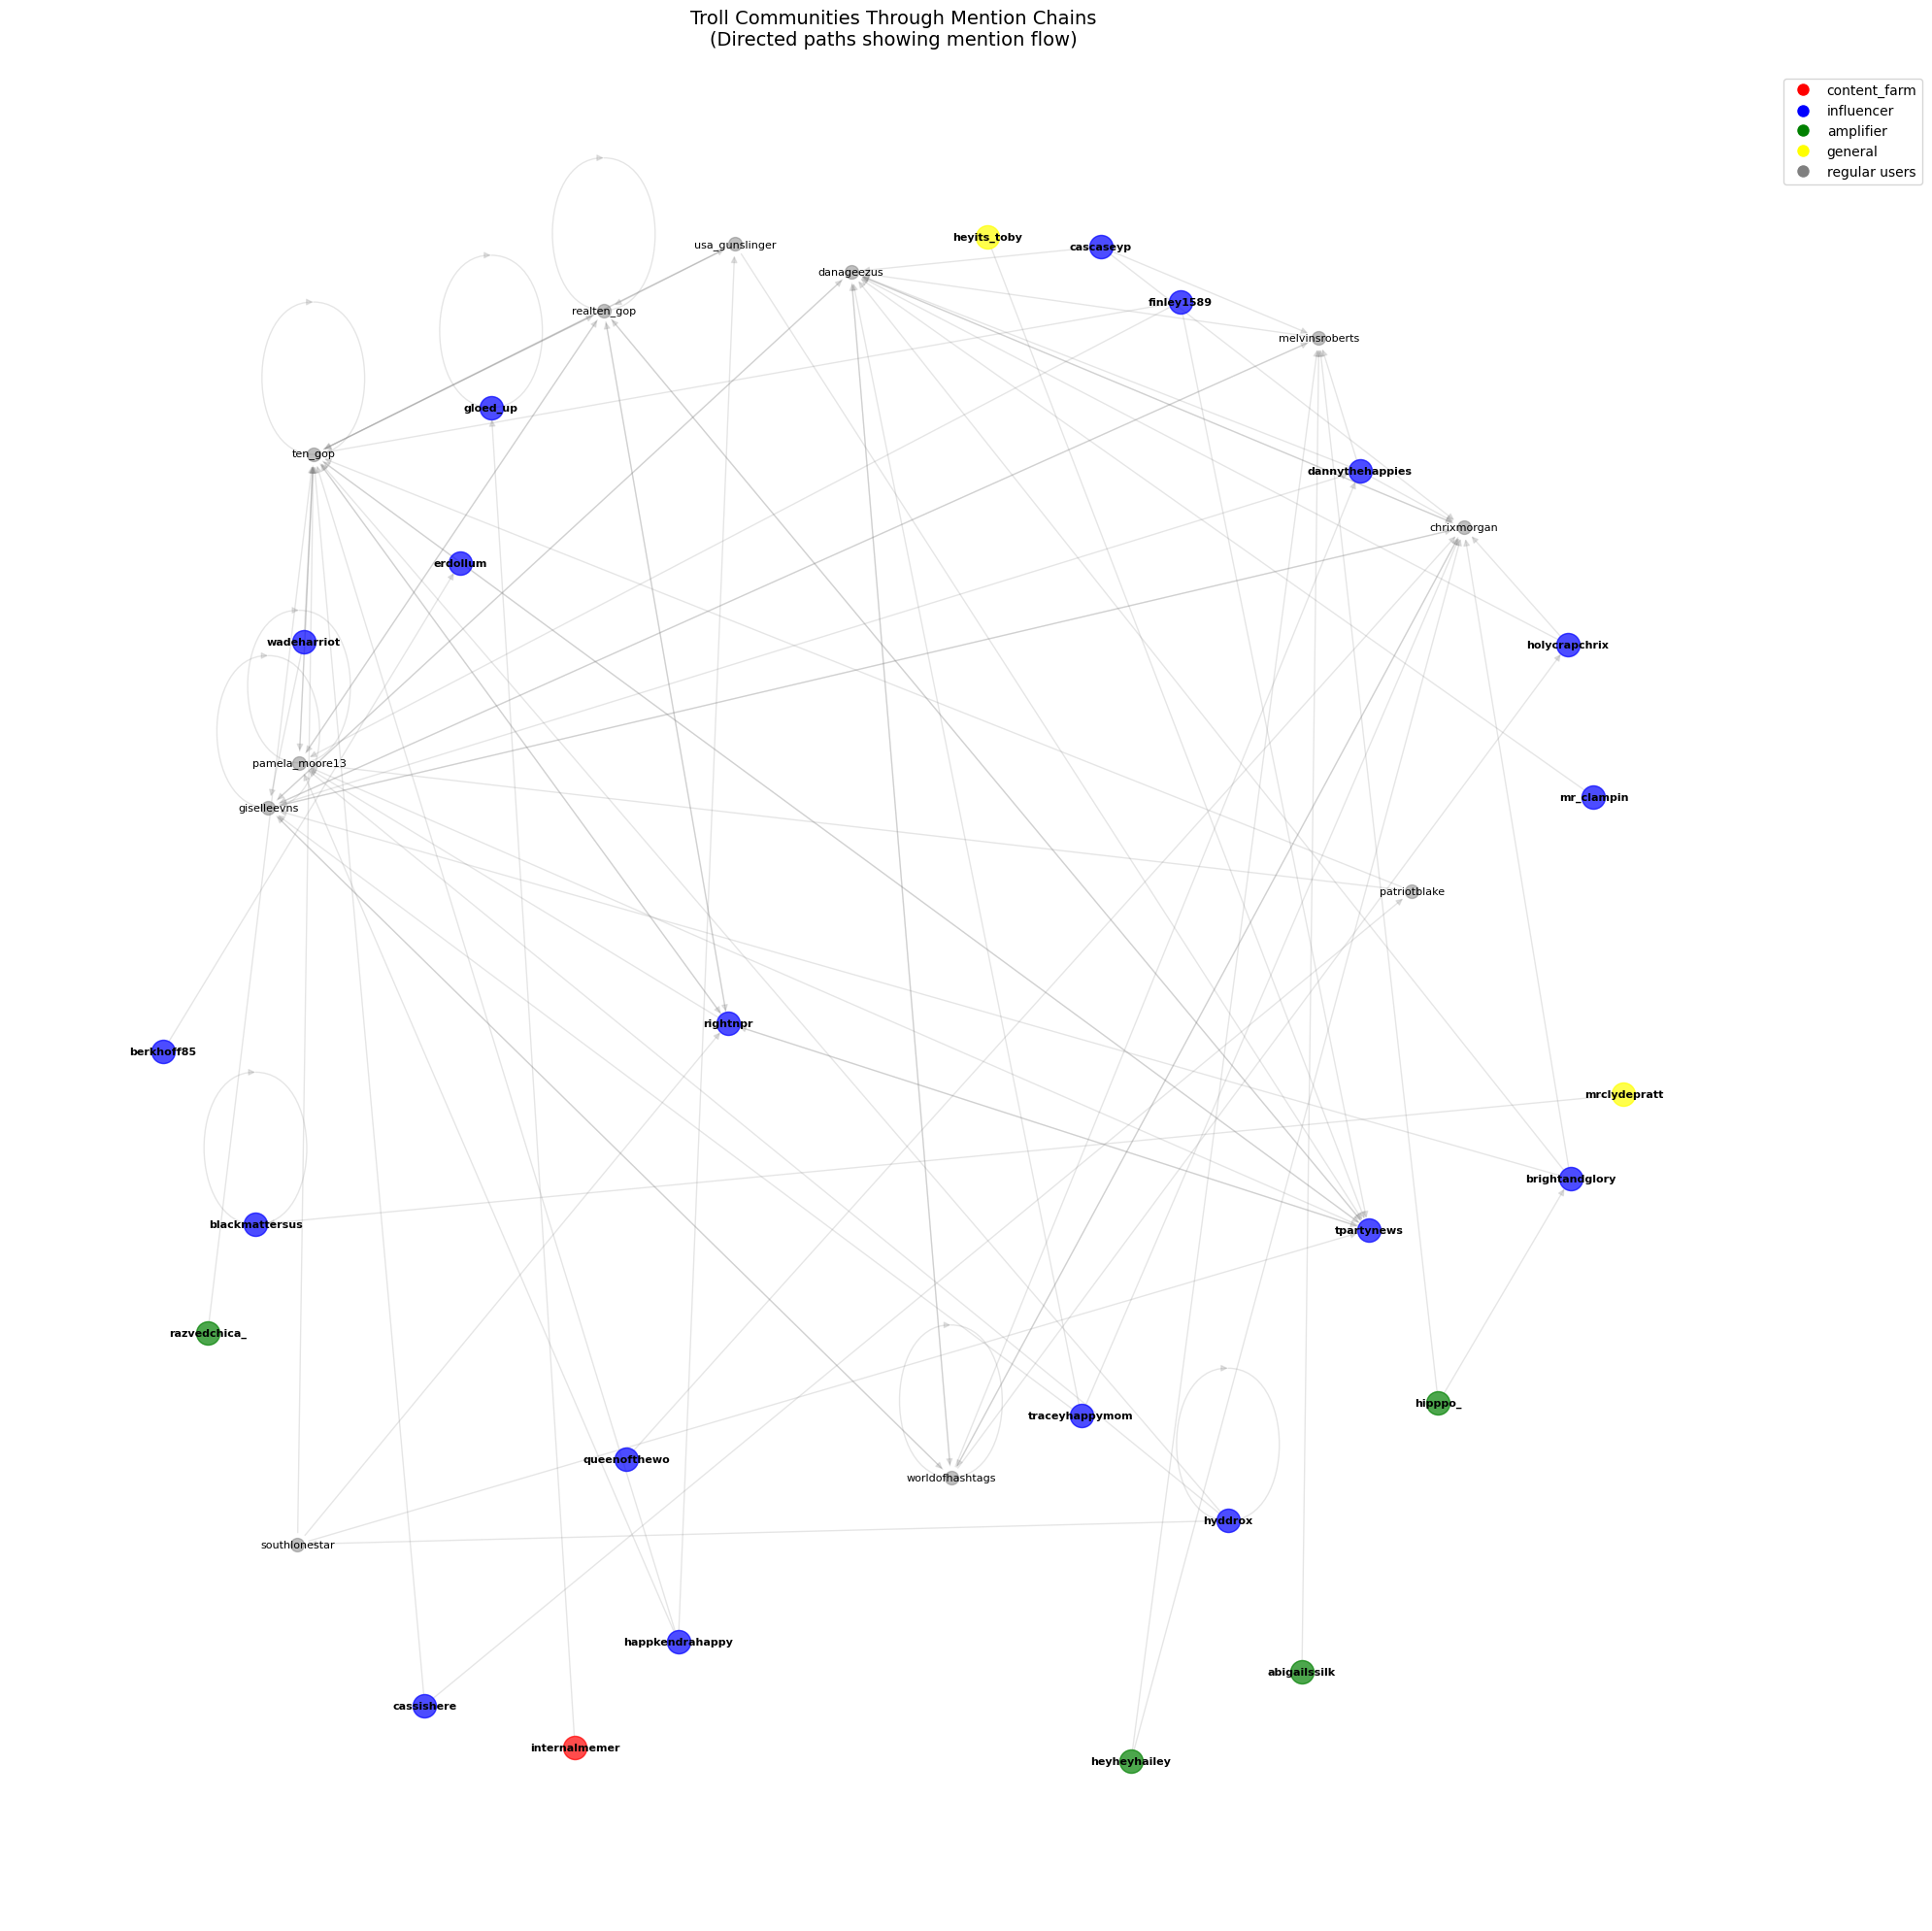


Total paths found: 142
Average path length: 3.72

Example paths:
heyits_toby -> tpartynews
hipppo_ -> brightandglory
mrclydepratt -> blackmattersus
tpartynews -> rightnpr
berkhoff85 -> erdollum

Graph Statistics:
Total nodes: 14273
Total edges: 33180
Original trolls: 104
Trolls in graph: 104


In [21]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import ast
from collections import defaultdict

# Read data
tweets_df = pd.read_csv('tweets.csv')
users_df = pd.read_csv('users.csv')

# Categorize trolls
def categorize_trolls(users_df, tweets_df):
    troll_categories = {}
    for _, user in users_df.iterrows():
        user_tweets = tweets_df[tweets_df['user_key'] == str(user['screen_name'])]
        tweet_count = len(user_tweets)
        
        if tweet_count == 0:
            continue
            
        retweet_count = user_tweets['retweeted_status_id'].notna().sum()
        retweet_ratio = retweet_count / tweet_count if tweet_count > 0 else 0
        
        if user['statuses_count'] > 1000 and user['followers_count'] < 100:
            troll_categories[user['screen_name']] = 'content_farm'
        elif user['followers_count'] > 1000 and user['listed_count'] > 10:
            troll_categories[user['screen_name']] = 'influencer'
        elif retweet_ratio > 0.7:
            troll_categories[user['screen_name']] = 'amplifier'
        else:
            troll_categories[user['screen_name']] = 'general'
            
    return troll_categories

# Get troll categories
troll_categories = categorize_trolls(users_df, tweets_df)

# Create directed graph
DG = nx.DiGraph()

# Convert mentions to list and process mentions
tweets_df['mentions'] = tweets_df['mentions'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

# Add nodes for all trolls first
for troll in troll_categories:
    DG.add_node(troll)

# Add edges based on mentions
for _, tweet in tweets_df.iterrows():
    source = tweet['user_key']
    mentions = tweet['mentions']
    
    if not DG.has_node(source):
        DG.add_node(source)
    
    for target in mentions:
        if not DG.has_node(target):
            DG.add_node(target)
        DG.add_edge(source, target)

def find_troll_communities(G, troll_categories, max_path_length=3):
    communities = []
    existing_trolls = set(troll_categories.keys()).intersection(set(G.nodes()))
    
    print(f"Number of trolls in graph: {len(existing_trolls)}")
    
    for troll1 in existing_trolls:
        for troll2 in existing_trolls:
            if troll1 != troll2:
                try:
                    paths = list(nx.all_simple_paths(G, troll1, troll2, cutoff=max_path_length))
                    communities.extend(paths)
                except nx.NetworkXNoPath:
                    continue
    
    return communities

print("Finding communities...")
communities = find_troll_communities(DG, troll_categories)
print(f"Found {len(communities)} paths")

if len(communities) > 0:
    # Create subgraph with community nodes
    community_nodes = set()
    for path in communities:
        community_nodes.update(path)
        
    subG = DG.subgraph(community_nodes)

    plt.figure(figsize=(20, 20))
    
    # Create layout with more space between nodes
    pos = nx.spring_layout(subG, k=2, iterations=50)

    # Define colors
    color_map = {
        'content_farm': 'red',
        'influencer': 'blue',
        'amplifier': 'green',
        'general': 'yellow'
    }

    # Draw nodes
    for node in subG.nodes():
        if node in troll_categories:
            nx.draw_networkx_nodes(subG, pos, 
                                 nodelist=[node],
                                 node_color=color_map[troll_categories[node]],
                                 node_size=300,
                                 alpha=0.7)
        else:
            nx.draw_networkx_nodes(subG, pos,
                                 nodelist=[node],
                                 node_color='gray',
                                 node_size=100,
                                 alpha=0.5)

    # Draw edges with arrows
    nx.draw_networkx_edges(subG, pos,
                          edge_color='gray',
                          alpha=0.2,
                          arrows=True,
                          arrowsize=10)

    # Add labels for all nodes with different colors and sizes
    labels = {}
    for node in subG.nodes():
        if node in troll_categories:
            # Troll labels in black, slightly larger
            labels[node] = node
        else:
            # Regular user labels in dark gray, slightly smaller
            labels[node] = node
    
    # Draw troll labels
    troll_labels = {n: l for n, l in labels.items() if n in troll_categories}
    nx.draw_networkx_labels(subG, pos, labels=troll_labels, 
                          font_size=8, font_weight='bold')
    
    # Draw user labels
    user_labels = {n: l for n, l in labels.items() if n not in troll_categories}
    nx.draw_networkx_labels(subG, pos, labels=user_labels,
                          font_size=8, font_color='black')

    # Legend
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                 markerfacecolor=color, label=category,
                                 markersize=10)
                      for category, color in color_map.items()]
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor='gray', label='regular users',
                                     markersize=10))
    plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

    plt.title("Troll Communities Through Mention Chains\n(Directed paths showing mention flow)",
             pad=20, size=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"\nTotal paths found: {len(communities)}")
    print(f"Average path length: {sum(len(p) for p in communities)/len(communities):.2f}")
    print("\nExample paths:")
    for path in sorted(communities, key=len)[:5]:
        print(" -> ".join(path))

print("\nGraph Statistics:")
print(f"Total nodes: {DG.number_of_nodes()}")
print(f"Total edges: {DG.number_of_edges()}")
print(f"Original trolls: {len(troll_categories)}")
print(f"Trolls in graph: {sum(1 for n in DG.nodes() if n in troll_categories)}")